## Two inputs winner-take-all
[Inputs] ──► (binding) ──► [Dimers / Trimers] 
        │
        └──► (as substrates) ──► [ES Complex (activation / inhibition)]
                                       │
                                       ├──► (cleavage) ──► [Activated products]
                                       └──► (cleavage) ──► [Inhibited products]

[Neurons] ──► (binding) ──► [Dimers / Trimers]
          │
          └──► (as substrates) ──► [ES Complex (activation / inhibition)]
                                       │
                                       ├──► (cleavage) ──► [Activated products]
                                       └──► (cleavage) ──► [Inhibited products]

[All species] ──► (synthesis)  
[All species] ──► (degradation)
[Outputs (Ys)] ◄── (produced mainly from activated products)

## package

In [18]:
pip install seaborn

^C
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/xinwenfan/opt/anaconda3/envs/biocircuits/lib/python3.13/site-packages/pip/__main__.py", line 24, in <module>
    sys.exit(_main())
  File "/Users/xinwenfan/opt/anaconda3/envs/biocircuits/lib/python3.13/site-packages/pip/_internal/cli/main.py", line 77, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
  File "/Users/xinwenfan/opt/anaconda3/envs/biocircuits/lib/python3.13/site-packages/pip/_internal/commands/__init__.py", line 119, in create_command
    module = importlib.import_module(module_path)
  File "/Users/xinwenfan/opt/anaconda3/envs/biocircuits/lib/python3.13/importlib/__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
import scipy.integrate as spi
import pandas as pd
import seaborn as sb
import glob
from matplotlib.colors import LinearSegmentedColormap

## initialize system

In [ ]:
def initialize_system(params, startingspecies):
	
  neurons_D = startingspecies.neurons
  inputs = startingspecies.inputs
  ys = startingspecies.ys
  xs_syn = params.xs_syn
  ys_syn = params.ys_syn
  ns_syn = params.ns_syn

  ########################Initialize the system
  #Initial dimer formation
  dimer_D, dimer_D_rates = initialize_binding_reactions(inputs,neurons_D,params.kon1,params.koff1,True) #Has to be this "inputs, neurons_D" order! 

  #Trimer formation
  trimer_D, trimer_D_rates = initialize_binding_reactions(ys,dimer_D,params.kon2,params.koff2,False) #Same, has to be in this order!

  ########################Cleavage being done by e.g. x1-n11D-y1
  #Cleave off DHFR tag from the neuron monomers
  ESComplex1, ESComplex1_rates = initialize_ES_Complex_activation_reactions(trimer_D,neurons_D,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  neurons, neurons_rates = initialize_cleavage_activation_reactions(ESComplex1,params.kcat1,params.kcat2,params.kcat3)

  #Cleave off DHFR tag off the dimers
  ESComplex2, ESComplex2_rates = initialize_ES_Complex_activation_reactions(trimer_D,dimer_D,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  dimer, dimer_rates = initialize_cleavage_activation_reactions(ESComplex2,params.kcat1,params.kcat2,params.kcat3)

  #Cleave off DHFR tag off the trimers
  ESComplex3, ESComplex3_rates = initialize_ES_Complex_activation_reactions(trimer_D,trimer_D,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  trimer, trimer_rates = initialize_cleavage_activation_reactions(ESComplex3,params.kcat1,params.kcat2,params.kcat3)

  #Cleave off ys from their fused half-proteases. ys_D are now basically just helical bundles
  ESComplex4, ESComplex4_rates = initialize_ES_Complex_inhibition_reactions(trimer_D,ys,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  ys_D, ys_D_rates = initialize_cleavage_inhibition_reactions(ESComplex4,params.kcat1,params.kcat2,params.kcat3)

  #Subsequent dimer formation
  dimer, dimer_rates_2 = initialize_binding_reactions(inputs,neurons,params.kon1,params.koff1,True) #Has to be this "inputs, neurons" order! 

  #Subsequent trimer formation
  trimer, trimer_rates_2 = initialize_binding_reactions(ys,dimer,params.kon2,params.koff2,False) #Same, has to be in this order!

  ########################Cleavage being done by e.g. x1-n11-y1
  #Cleave off DHFR tag from the neuron monomers
  ESComplex5, ESComplex5_rates = initialize_ES_Complex_activation_reactions(trimer,neurons_D,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  neurons, neurons_rates_2 = initialize_cleavage_activation_reactions(ESComplex5,params.kcat1,params.kcat2,params.kcat3)

  #Cleave off DHFR tag off the dimers
  ESComplex6, ESComplex6_rates = initialize_ES_Complex_activation_reactions(trimer,dimer_D,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  dimer, dimer_rates_3 = initialize_cleavage_activation_reactions(ESComplex6,params.kcat1,params.kcat2,params.kcat3)

  #Cleave off DHFR tag off the trimers
  ESComplex7, ESComplex7_rates = initialize_ES_Complex_activation_reactions(trimer,trimer_D,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  trimer, trimer_rates_3 = initialize_cleavage_activation_reactions(ESComplex7,params.kcat1,params.kcat2,params.kcat3)

  #Cleave off ys from their fused half-proteases. ys_D are now basically just helical bundles
  ESComplex8, ESComplex8_rates = initialize_ES_Complex_inhibition_reactions(trimer,ys,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  ys_D, ys_D_rates_2 = initialize_cleavage_inhibition_reactions(ESComplex8,params.kcat1,params.kcat2,params.kcat3)

  #Formation of trimers containing ys_D. Both forms are non-enzymes. 
  #Trimer formation
  trimer_D_ys_D, trimer_D_ys_D_rates = initialize_binding_reactions(ys_D,dimer_D,params.kon2,params.koff2,False) #Same, has to be in this order!
  #Trimer formation
  trimer_ys_D, trimer_ys_D_rates = initialize_binding_reactions(ys_D,dimer,params.kon2,params.koff2,False) #Same, has to be in this order!

  ########################First, account for the new "substrate": trimer_D_ys_D
  #Cleave off DHFR tag from the neuron monomers
  ESComplex9, ESComplex9_rates = initialize_ES_Complex_activation_reactions(trimer_D,trimer_D_ys_D,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  trimer_ys_D, trimer_ys_D_rates_2 = initialize_cleavage_activation_reactions(ESComplex9,params.kcat1,params.kcat2,params.kcat3)
  #Cleave off DHFR tag from the neuron monomers
  ESComplex10, ESComplex10_rates = initialize_ES_Complex_activation_reactions(trimer,trimer_D_ys_D,params.kon_p1,params.koff_p1,params.kon_p2,params.koff_p2,params.kon_p3,params.koff_p3,True)
  trimer_ys_D, trimer_ys_D_rates_3 = initialize_cleavage_activation_reactions(ESComplex10,params.kcat1,params.kcat2,params.kcat3)

  ########################Synthesis
  xs_rate_syn = initialize_synthesis_reactions(xs_syn, params.cell*params.avgd)
  neurons_D_rate_syn = initialize_synthesis_reactions(ns_syn, params.cell*params.avgd)
  ys_rate_syn = initialize_synthesis_reactions(ys_syn, params.cell*params.avgd)

  ########################Degradation
  dimer_D_deg_rate = initialize_degradation_reactions(dimer_D,params.deg_DHFR)
  trimer_D_deg_rate = initialize_degradation_reactions(trimer_D,params.deg_DHFR)
  neurons_deg_rate = initialize_degradation_reactions(neurons,params.deg_reg)
  dimer_deg_rate = initialize_degradation_reactions(dimer,params.deg_reg)
  trimer_deg_rate = initialize_degradation_reactions(trimer,params.deg_reg)
  ys_D_deg_rate = initialize_degradation_reactions(ys_D,params.deg_reg)
  trimer_D_ys_D_deg_rate = initialize_degradation_reactions(trimer_D_ys_D,params.deg_DHFR)
  trimer_ys_D_deg_rate = initialize_degradation_reactions(trimer_ys_D,params.deg_reg)
  inputs_deg_rate = initialize_degradation_reactions(inputs,params.deg_reg)
  neurons_D_deg_rate = initialize_degradation_reactions(neurons_D,params.deg_DHFR)
  ys_deg_rate = initialize_degradation_reactions(ys,params.deg_reg)

  ########################Set up the ODE solver
  #First merge all species and reaction rates
  all_species_dict = {}
  for d in [dimer_D, trimer_D, neurons, dimer, trimer, ys_D, trimer_D_ys_D, \
            trimer_ys_D, inputs, neurons_D, ys, ESComplex1, ESComplex2, \
            ESComplex3, ESComplex4, ESComplex5, ESComplex6, ESComplex7, \
            ESComplex8, ESComplex9, ESComplex10]:
    all_species_dict.update(d)

  all_reactions = dimer_D_rates + trimer_D_rates + ESComplex1_rates + \
    neurons_rates + ESComplex2_rates + dimer_rates + ESComplex3_rates + \
    trimer_rates + ESComplex4_rates + ys_D_rates + dimer_rates_2 + \
    trimer_rates_2 + ESComplex5_rates + neurons_rates_2 + ESComplex6_rates + \
    dimer_rates_3 + ESComplex7_rates + trimer_rates_3 + ESComplex8_rates + \
    ys_D_rates_2 + trimer_D_ys_D_rates + trimer_ys_D_rates + ESComplex9_rates + \
    trimer_ys_D_rates_2 + ESComplex10_rates + trimer_ys_D_rates_3 + xs_rate_syn + \
    neurons_D_rate_syn + ys_rate_syn + dimer_D_deg_rate + trimer_D_deg_rate + \
    neurons_deg_rate + dimer_deg_rate + trimer_deg_rate + ys_D_deg_rate + \
    trimer_D_ys_D_deg_rate + trimer_ys_D_deg_rate + inputs_deg_rate + \
    neurons_D_deg_rate + ys_deg_rate 

  return all_species_dict, all_reactions

## initialize binding reactions

In [ ]:
def initialize_binding_reactions(in1,in2,kon,koff,check_binding): #set check_binding to 1 to check if two proteins can bind by design
  rate_list=[]
  out_dict={}
  for i in in1:
    for j in in2:
      can_bind=True
      if check_binding:
        can_bind=(i[1]==j[1])
      if can_bind:
        out_dict[i+"-"+j]=0
        rate_list.append((i,-kon,i,j)) #first item is chemical species of interst, its rate of change is -kon*i*j
        rate_list.append((j,-kon,i,j))
        rate_list.append((i+"-"+j,-koff,i+"-"+j))
        rate_list.append((i,koff,i+"-"+j))
        rate_list.append((j,koff,i+"-"+j))
        rate_list.append((i+"-"+j,kon,i,j))
  return out_dict, rate_list

## initialize synthesis reactions

In [ ]:
def initialize_synthesis_reactions(rate_dict,correction_factor): #rate_dict is a dictionary of synthesis rates
  rate_list=[]
  for i in list(rate_dict.keys()):
    rate_list.append((i,rate_dict[i]/correction_factor)) #correct for cell volume
  return rate_list

## initialize degradation reactions

In [ ]:
def initialize_degradation_reactions(in1,k):
  rate_list=[]
  for i in in1:
    rate_list.append((i,-k,i))
  return rate_list

## initialize ES Complex activation reactions

In [ ]:
def initialize_ES_Complex_activation_reactions(enzyme,substrate,kon_p1,koff_p1,kon_p2,koff_p2,kon_p3,koff_p3,check_binding):#Enzyme can only form ES complex with its designated substrate
  rate_list=[]
  out_dict={}
  for i in enzyme:
    for j in substrate:
      can_bind=functional_protease=True
      if check_binding:
        enz_identifier_index=i.index('n')+2
        functional_protease=(i[1]==i[enz_identifier_index]) # e.g. y1D-x2-n21D
        can_bind=(i[1]==j[-2]) # e.g. y1D-x1-n11D can cleave n21D
      if (can_bind and functional_protease):
        if int(i[enz_identifier_index])==1:
          kon=kon_p1
          koff=koff_p1
        elif int(i[enz_identifier_index])==2:
          kon=kon_p2
          koff=koff_p2
        elif int(i[enz_identifier_index])==3:
          kon=kon_p3
          koff=koff_p3
        out_dict[i+"_"+j]=0
        rate_list.append((i,-kon,i,j)) #first item is chemical species of interst, its rate of change is -kon*i*j
        rate_list.append((j,-kon,i,j))
        rate_list.append((i+"_"+j,-koff,i+"_"+j))
        rate_list.append((i,koff,i+"_"+j))
        rate_list.append((j,koff,i+"_"+j))
        rate_list.append((i+"_"+j,kon,i,j))
  return out_dict, rate_list

## initialize ES Complex inhibition reactions

In [ ]:
def initialize_ES_Complex_inhibition_reactions(enzyme,substrate,kon_p1,koff_p1,kon_p2,koff_p2,kon_p3,koff_p3,check_binding):#Enzyme can only form ES complex with its designated substrate
  rate_list=[]
  out_dict={}
  for i in enzyme:
    for j in substrate:
      can_bind=functional_protease=True
      if check_binding:
        enz_identifier_index=i.index('n')+2
        functional_protease=(i[1]==i[enz_identifier_index]) # e.g. y1D-x2-n21D
        can_bind=(i[1]!=j[1]) # e.g. y1D-x1-n11D can cleave y2
      if (can_bind and functional_protease):
        if int(i[enz_identifier_index])==1:
          kon=kon_p1
          koff=koff_p1
        elif int(i[enz_identifier_index])==2:
          kon=kon_p2
          koff=koff_p2
        elif int(i[enz_identifier_index])==3:
          kon=kon_p3
          koff=koff_p3
        out_dict[i+"_"+j]=0
        rate_list.append((i,-kon,i,j)) #first item is chemical species of interst, its rate of change is -kon*i*j
        rate_list.append((j,-kon,i,j))
        rate_list.append((i+"_"+j,-koff,i+"_"+j))
        rate_list.append((i,koff,i+"_"+j))
        rate_list.append((j,koff,i+"_"+j))
        rate_list.append((i+"_"+j,kon,i,j))
  return out_dict, rate_list

## initialize cleavage activation reactions

In [ ]:
def initialize_cleavage_activation_reactions(ES_complex,kcat1,kcat2,kcat3): #cleaving off the DHFR
  rate_list=[]
  out_dict={}
  for i in ES_complex:
    if int(i[1])==1:
      k=kcat1
    elif int(i[1])==2:
      k=kcat2
    elif int(i[1])==3:
      k=kcat3
    enzyme=i.split("_")[0]
    substrate=i.split("_")[1]
    product=substrate[0:-1]
    out_dict[product]=0
    rate_list.append((i,-k,i))
    rate_list.append((enzyme,k,i))
    rate_list.append((product,k,i))
  return out_dict, rate_list

## initialize cleavage inhibition reactions

In [ ]:
def initialize_cleavage_inhibition_reactions(ES_complex,kcat1,kcat2,kcat3): #cleaving off half proteases from ys
  rate_list=[]
  out_dict={}
  for i in ES_complex:
    if int(i[1])==1:
      k=kcat1
    elif int(i[1])==2:
      k=kcat2
    elif int(i[1])==3:
      k=kcat3
    enzyme=i.split("_")[0]
    substrate=i.split("_")[1]
    product=substrate+"D"
    out_dict[product]=0
    rate_list.append((i,-k,i))
    rate_list.append((enzyme,k,i))
    rate_list.append((product,k,i))
  return out_dict, rate_list

## ode

In [ ]:
#Populate ODEs
def write_ODEs(species, t):
  ODEs=[]
  for s in all_species_dict:
    dsdt=0
    for r in all_reactions:
      if s==r[0]:
        multiple=1
        if len(r)>2: #Need to account for synthesis, where there is just a single rate constant
          for i in range(2,len(r)):
            index_of_species=list(all_species_dict.keys()).index(r[i]);
            multiple=multiple*species[index_of_species]
        dsdt=dsdt+multiple*float(r[1])
    ODEs.append(dsdt)
  return ODEs

def get_results(plot_names, results_vector, t): #get results from the ODE solver
  results=np.zeros(len(t))
  for i in plot_names:
    temp_vect=[]
    index_of_species=list(all_species_dict.keys()).index(i)
    for j in results_vector:
      temp_vect.append(j[index_of_species])
    results = [results[i] + temp_vect[i] for i in range(len(results))] 
  return results

## plot

In [ ]:
def make_plot(num_inputs, num_neurons, out_species, species_names, time, dirname, save_data):
  # Default plot settings
  plt.rcParams.update({'font.size': 17})
  fig, ax = plt.subplots()
  plt.xlabel("Time (Hour)")
  plt.ylabel("Concentration (M)")
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)
  # Automatically generate names of reconstituted proteases species for plotting
  plot_legend = []
  colors = ['#E9232A', '#CFDA32', '#89CFF0', '#BF40BF']
  data_vec = []
  for i in range(1, num_neurons+1):
    plot_names = []
    plot_legend.append('Neuron '+str(i))
    for j in range(1, num_inputs+1):
      possible_species = 'y'+str(i)+'-x'+str(j)+'-n'+str(j)+str(i)
      if possible_species in species_names:
        plot_names.append(possible_species)
        plot_names.append(possible_species + 'D')
    total_protease_concen = get_results(plot_names, out_species, time)
    ax.plot(time/3600, total_protease_concen, linewidth=5, color = colors[i-1])
    data_vec.append(total_protease_concen)
  plt.legend(plot_legend, shadow=True)
  plt.show()
  if (save_data):
    pickle.dump( [time/3600, data_vec], open( dirname, "wb" ) )
  return fig

## params

In [ ]:
class Params(object):
    """
    Container for parameters
    """
    def __init__(self, **kwargs):
        # Parameters taken from bionumbers
        self.kon1 = 10**5 # per second per M. Andrew Hunt measurement. First step binding to form dimers. 
        self.koff1 = 100 # per second. Andrew Hunt measurement. First step binding to form dimers. 
        self.kon2 = 10**5 # per second per M. Andrew Hunt measurement. Second step binding to form trimers. 
        self.koff2 = 10**-4 # per second. Andrew Hunt measurement. Second step binding to form trimers. 
        self.kon_p1 = 10**5 # kon for protease 1
        self.koff_p1 = 10**-4 #koff for protease 1
        self.kon_p2 = 10**5 # kon for protease 2
        self.koff_p2 = 10**-4 #koff for protease 2
        self.kon_p3 = 10**5 # kon for protease 3
        self.koff_p3 = 10**-4 #koff for protease 3
        self.deg_reg = 1E-5 # per second. https://bionumbers.hms.harvard.edu/bionumber.aspx?id=112253&ver=1&trm=degradation+rate&org=
        self.deg_DHFR = 1E-3 # 100 fold faster according to Xiaojing
        self.kcat1 = 0.16 # per second, from https://febs.onlinelibrary.wiley.com/doi/full/10.1111/j.1742-4658.2004.04493.x
        self.kcat2 = 0.16 # per second, from https://febs.onlinelibrary.wiley.com/doi/full/10.1111/j.1742-4658.2004.04493.x
        self.kcat3 = 0.16 # per second, from https://febs.onlinelibrary.wiley.com/doi/full/10.1111/j.1742-4658.2004.04493.x
        self.cell = 4E-15 # L
        self.avgd = 6.02E23 # Avogadro's number
        # Synthesis rates, in molecules per second
        self.xs_syn = {"x1":0.07, "x2":0.05}
        self.ns_syn = {"n11D":0.6, "n12D":0, "n21D":0, "n22D":0.6}
        self.ys_syn = {"y1":0.6, "y2":0.6}

        # Allow addition of new params
        for entry in kwargs:
            setattr(self, entry, kwargs[entry])

## starting species

In [ ]:
class StartingSpecies(object):
    """
    Container for initla chemical species
    """
    def __init__(self, **kwargs):
        # Amount of initial chemical species, default to zero
        self.inputs = {"x1":0, "x2":0}
        self.neurons = {"n11D":0, "n12D":0, "n21D":0, "n22D":0}
        self.ys = {"y1":0, "y2":0}

        # Allow addition of new chemical species
        for entry in kwargs:
            setattr(self, entry, kwargs[entry])

## MAIN FUNCTION

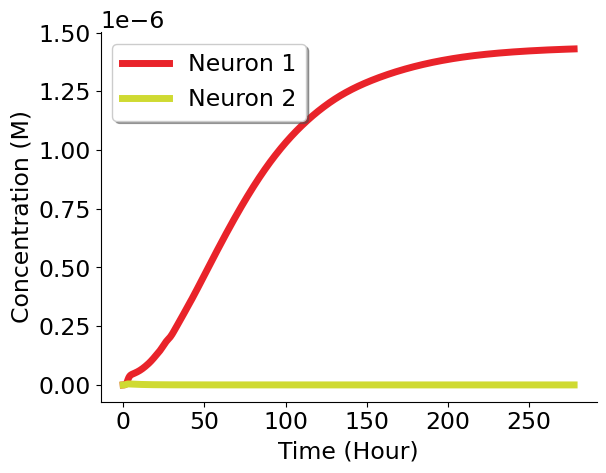

FileNotFoundError: [Errno 2] No such file or directory: '/Users/xinwenfan/Documents/scripts/perceptein/wtann/initial_test.pickle'

In [ ]:
if __name__ == '__main__':
    working_dir = "/Users/xinwenfan/Documents/scripts/perceptein/wtann/"
    file_name = 'initial_test'

    #Time this run
    start_time = time.time()

    #Initialize the system
    params = Params() # Can set/add params, e.g. params.xs_syn["syn_x3"] = 0.07 or params.deg_DHFR = 1E-5
    params.xs_syn["x1"] = 0.07
    params.xs_syn["x2"] = 0.05
    params.ns_syn["n11D"] = 0.6
    params.ns_syn["n12D"] = 0.0
    params.ns_syn["n21D"] = 0.0
    params.ns_syn["n22D"] = 0.6
#     params.ys_syn["y1"] = 10
#     params.ys_syn["y2"] = 10
    startingspecies = StartingSpecies()
    all_species_dict, all_reactions = initialize_system(params, startingspecies)

    #Solve the system of ODEs
    initial_condition = np.zeros(len(all_species_dict))
    t = np.linspace(0., 1E6, num=int(1E6))
    species = spi.odeint(write_ODEs, initial_condition, t)

    #Make plots
    species_names = list(all_species_dict.keys())
    num_inputs = len(startingspecies.inputs)
    num_neurons = len(startingspecies.ys)
    fig = make_plot(num_inputs, num_neurons, species, species_names, t, working_dir + file_name + ".pickle", True)

    #Time this run
    print ("--- %s seconds ---" % (time.time() - start_time))
    print ("Number of species: "+str(len(all_species_dict)))
    print ("Number of reactions: "+str(len(all_reactions)))

    fig.savefig(working_dir + file_name + ".svg")
    
#     #Dump data
#     with open(working_dir + file_name + '.pickle', 'wb') as f:
#         # Pickle the 'data' dictionary using the highest protocol available.
#         pickle.dump([species, species_names, t], f)

In [20]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 1.8 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


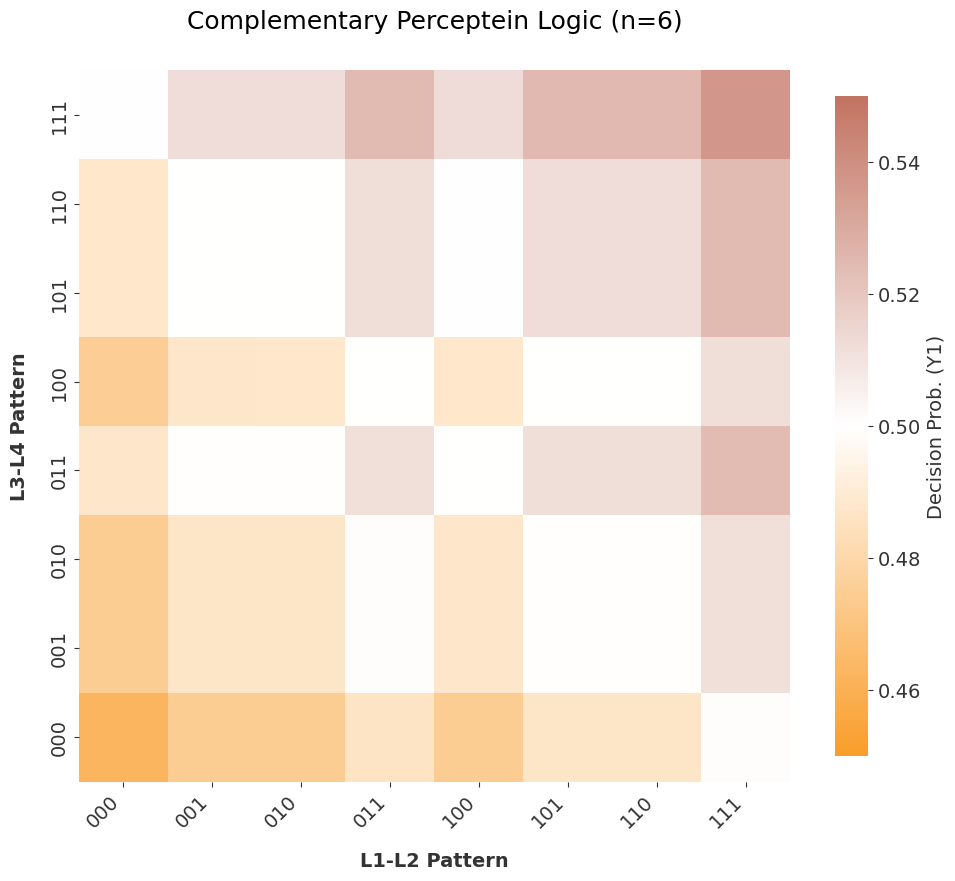

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================
# REFINED PARAMETERS (n=4 Complementary Model)
# =============================================================================
n = 6               
num_cells = 300     
beta = 0.1         
# =============================================================================

# Style configuration
plt.rcParams.update({
    'font.size': 14,
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'font.family': 'sans-serif'
})

def run_complementary_simulation(n_dim, cell_count, softmax_beta):
    """
    Computes decisions based on Complementary Input Logic:
    X1 responds to Presence (L), X2 responds to Absence (1-L).
    """
    np.random.seed(42)
    # Generate all binary environmental states
    all_combs = list(itertools.product([0, 1], repeat=n_dim))
    # Random Weights for the population
    W = np.random.rand(cell_count, 2, n_dim) * 0.5
    
    results = []
    for comb in all_combs:
        L = np.array(comb)
        # Complementary logic: Absence of ligands
        L_inv = 1 - L 
        
        votes_y1 = 0
        for c in range(cell_count):
            # X1 driven by L, X2 driven by L_inv
            syn_X1 = np.dot(W[c, 0, :], L)
            syn_X2 = np.dot(W[c, 1, :], L_inv)
            
            # Winner-Take-All competition
            exp_X = np.exp(softmax_beta * np.array([syn_X1, syn_X2]))
            votes_y1 += (exp_X / np.sum(exp_X))[0]
            
        results.append(votes_y1 / cell_count)
    return np.array(results), all_combs

# 1. Execute Computation
data_flat, combinations = run_complementary_simulation(n, num_cells, beta)

# 2. Reshape for n=4 Grid (L1-L2 on X, L3-L4 on Y)
dim = 2**(n // 2)
matrix = data_flat.reshape(dim, dim).T # Aligning L1-L2 to X-axis

# 3. Labeling and Aesthetics
labels = ["".join(map(str, p)) for p in itertools.product([0, 1], repeat=n//2)]

# Dynamic and Symmetric Color Scaling
diff = max(np.max(np.abs(matrix - 0.5)), 0.05)
vmin, vmax = 0.5 - diff, 0.5 + diff

custom_cmap = LinearSegmentedColormap.from_list("PercepteinStyle", ["#F99D2A", "#FFFFFF", "#C27361"])

# 4. Final Visualization
fig, ax = plt.subplots(figsize=(10, 10))

# Shortened colorbar (shrink=0.45), 2 decimal points
sns.heatmap(matrix, cmap=custom_cmap, center=0.5, vmin=vmin, vmax=vmax,
            square=True, annot=False, xticklabels=labels, yticklabels=labels,
            cbar_kws={'format': '%.2f', 'shrink': 0.7, 'label': 'Decision Prob. (Y1)'},
            ax=ax)

ax.invert_yaxis() # Origin at bottom-left

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("L1-L2 Pattern", fontweight='bold', labelpad=15)
ax.set_ylabel("L3-L4 Pattern", fontweight='bold', labelpad=15)
ax.set_title(f"Complementary Perceptein Logic (n={n})", fontsize=18, pad=30)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

Specializing cells into logic buckets...


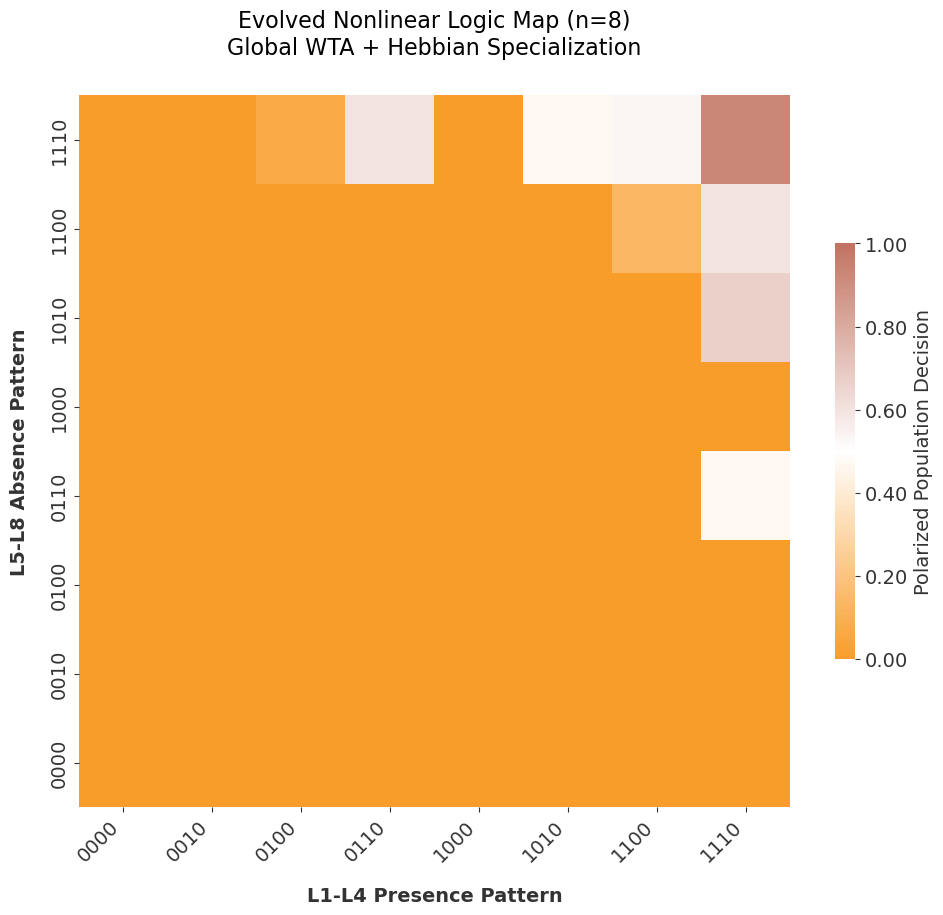

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================
# HYPERPARAMETERS (Optimized for Logic Block Emergence)
# =============================================================================
n = 8               # Input dimensionality (L1-L8)
tick_count = 8     # Grid resolution (8x8)
num_cells = 300     # Population size (Kenyon Cells)
k_winners = 15      # Top-K global winners (5% of population) 
train_beta = 10.0   # Sensitivity during Hebbian learning
inf_beta = 50.0     # High sensitivity for inference polarization
eta = 0.05          # Learning rate
epochs = 5          # Adaptive epochs
# =============================================================================

# Style matching the reference
plt.rcParams.update({'font.size': 14, 'font.family': 'sans-serif'})

def train_competitive_population(n_dim, cell_count, lr, s_train, n_epochs, k):
    """
    Trains the population using Global Top-K WTA and Hebbian Rule.
    Ensures cells specialize in different environmental motifs.
    """
    np.random.seed(42)
    # Gaussian initialization is more effective in breaking symmetry 
    W1 = np.random.randn(cell_count, n_dim) * 0.2
    W2 = np.random.randn(cell_count, n_dim) * 0.2
    
    all_states = list(itertools.product([0, 1], repeat=n_dim))
    
    for _ in range(n_epochs):
        np.random.shuffle(all_states)
        for state in all_states:
            L = np.array(state)
            L_inv = 1 - L # Presence vs Absence logic
            
            # 1. Calculate individual cell scores
            u = np.dot(W1, L)
            v = np.dot(W2, L_inv)
            cell_scores = u - v # Differential potential
            
            # 2. Global Soft-WTA (Softmax across population)
            exp_scores = np.exp(s_train * (cell_scores - np.max(cell_scores)))
            pop_activations = exp_scores / np.sum(exp_scores)
            
            # 3. Hebbian Update for all active cells 
            # Weights follow the input data density
            for c in range(cell_count):
                W1[c, :] += lr * pop_activations[c] * (L - u[c] * W1[c, :])
                W2[c, :] += lr * pop_activations[c] * (L_inv - v[c] * W2[c, :])
                
    return W1, W2

# 1. Training Phase
print("Specializing cells into logic buckets...")
W1_f, W2_f = train_competitive_population(n, num_cells, eta, train_beta, epochs, k_winners)

# 2. Inference with Global WTA
n_half = n // 2
pats = list(itertools.product([0, 1], repeat=n_half))
step = len(pats) // tick_count
selected = pats[::step][:tick_count]

matrix = np.zeros((tick_count, tick_count))
for y_idx, y_pat in enumerate(selected):
    for x_idx, x_pat in enumerate(selected):
        L = np.array(x_pat + y_pat)
        L_inv = 1 - L
        
        # Calculate scores across the whole population
        u = np.dot(W1_f, L)
        v = np.dot(W2_f, L_inv)
        cell_scores = u - v
        
        # Global WTA: Only the Top-K neurons contribute to the final decision
        # This prevents the "blank" averaging effect
        idx_winners = np.argsort(np.abs(cell_scores))[-k_winners:]
        winner_probs = 1 / (1 + np.exp(-inf_beta * cell_scores[idx_winners]))
        matrix[y_idx, x_idx] = np.mean(winner_probs)

# 3. Visualization
labels = ["".join(map(str, p)) for p in selected]
# Dynamically stretch colorbar based on actual polarization
diff = max(np.max(np.abs(matrix - 0.5)), 0.1)
vmin, vmax = 0.5 - diff, 0.5 + diff
custom_cmap = LinearSegmentedColormap.from_list("Style", ["#F99D2A", "#FFFFFF", "#C27361"])

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(matrix, cmap=custom_cmap, center=0.5, vmin=vmin, vmax=vmax,
            square=True, annot=False, xticklabels=labels, yticklabels=labels,
            cbar_kws={'format': '%.2f', 'shrink': 0.45, 'label': 'Polarized Population Decision'})

ax.invert_yaxis()
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("L1-L4 Presence Pattern", fontweight='bold', labelpad=15)
ax.set_ylabel("L5-L8 Absence Pattern", fontweight='bold', labelpad=15)
ax.set_title(f"Evolved Nonlinear Logic Map (n={n})\nGlobal WTA + Hebbian Specialization", fontsize=16, pad=30)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()